In [1]:
!pip install datasets -q

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete!")

Setup complete!


### Step 1: Load and Subset the Data
We will use `load_dataset("stanfordnlp/imdb")`. To save time and memory, we will only use the first 5,000 rows for training and 1,000 for testing.

In [7]:
# Load dataset
dataset = load_dataset("stanfordnlp/imdb")

# Shuffle train data
train_data = dataset['train'].shuffle(seed=42)

X_train = train_data['text'][:5000]
y_train = train_data['label'][:5000]

# Shuffle test data
test_data = dataset['test'].shuffle(seed=42)

X_test = test_data['text'][:1000]
y_test = test_data['label'][:1000]

print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")
print("Classes in training set:", set(y_train))

Loaded 5000 training reviews and 1000 testing reviews.
Classes in training set: {0, 1}


### Step 2: Word to Math (TF-IDF)
Machines can't read English. We need to convert these text reviews into numbers using a `TfidfVectorizer`.

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Data vectorized!")

Data vectorized!


### Step 3: Train the Model
Time to train the Classical ML algorithm: Logistic Regression.

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


### Step 4: Evaluate
How good is your AI movie critic? Let's predict on the test set and calculate the metrics.

In [10]:
y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8470
F1 Score: 0.8462

Confusion Matrix:
[[426  86]
 [ 67 421]]


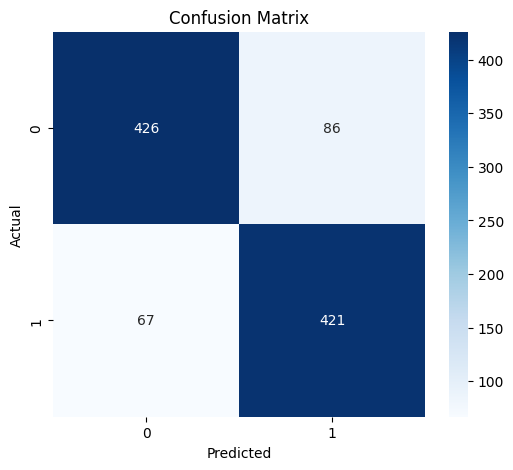

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()